In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


In [2]:
file_path = 'Cleaned_Hotel_Reservations.csv'
data = pd.read_csv(file_path)

In [3]:
plt.figure(figsize=(15, 12))


<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

In [4]:
#I believe booking ID is useless for this and not to mention messes up the EDA. Let's remove it.

data = data.drop(columns=['Booking_ID'])

data.head(10)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,date_of_arrival
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,65.00,0,Not_Canceled,2017-10-02
1,2,0,2,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled,2018-11-06
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,60.00,0,Canceled,2018-02-28
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,0,Canceled,2018-05-20
4,2,0,1,1,Not Selected,0,Room_Type 1,48,Online,0,0,0,94.50,0,Canceled,2018-04-11
5,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,Online,0,0,0,115.00,1,Canceled,2018-09-13
6,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,Online,0,0,0,107.55,1,Not_Canceled,2017-10-15
7,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,Online,0,0,0,105.61,1,Not_Canceled,2018-12-26
8,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,Offline,0,0,0,96.90,1,Not_Canceled,2018-07-06
9,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,Online,0,0,0,133.44,3,Not_Canceled,2018-10-18


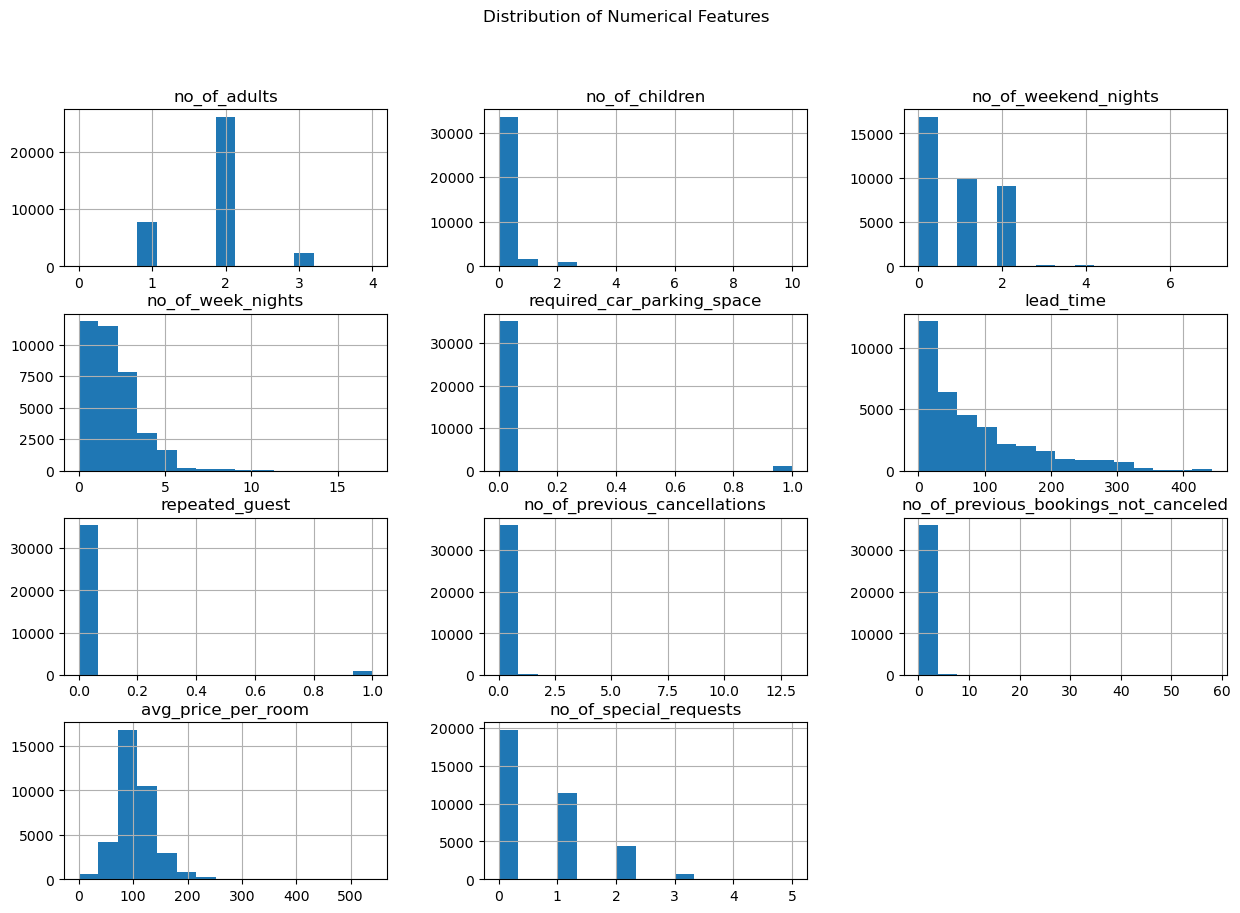

In [5]:
#I'm curious about the numerical columns. Let's check it out.

num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[num_cols].hist(bins=15, figsize=(15, 10))
plt.suptitle('Distribution of Numerical Features')
plt.show()

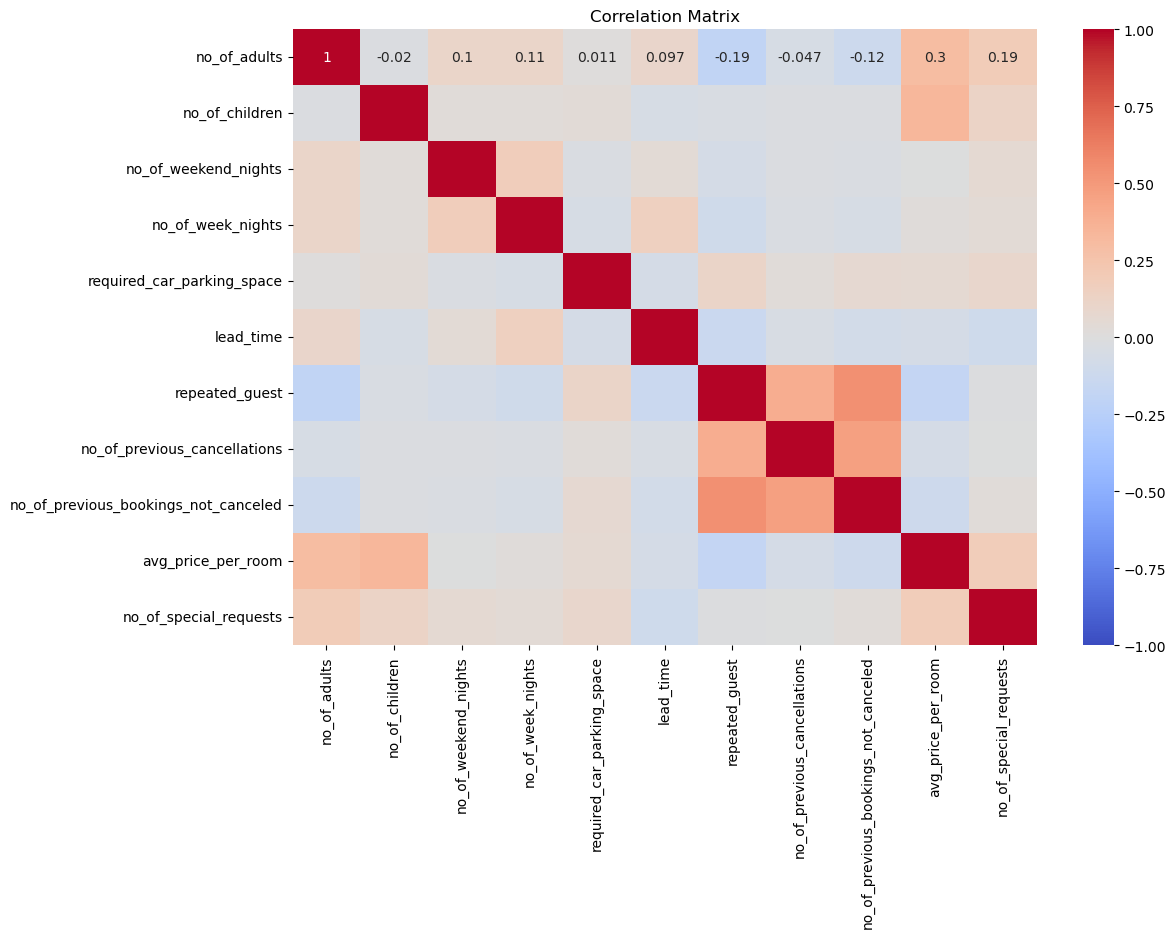

In [26]:
#Let's explore what the heatmap says.

# Select only numeric columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
numeric_data = data[numeric_cols]

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

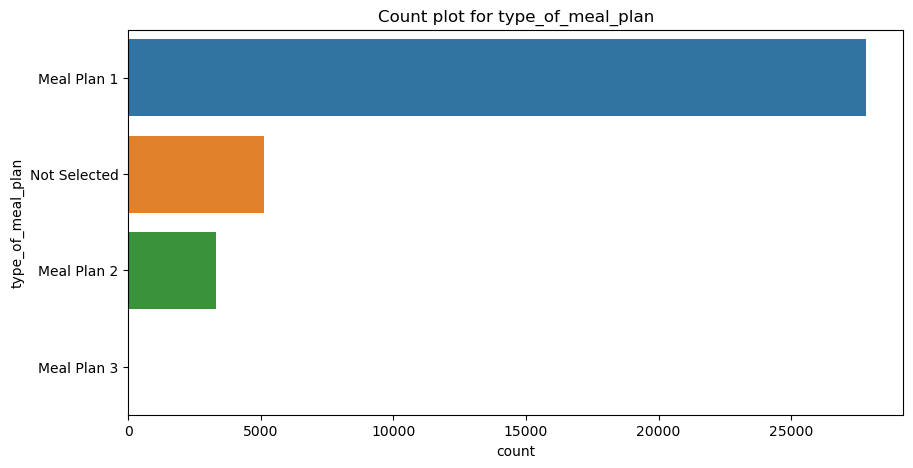

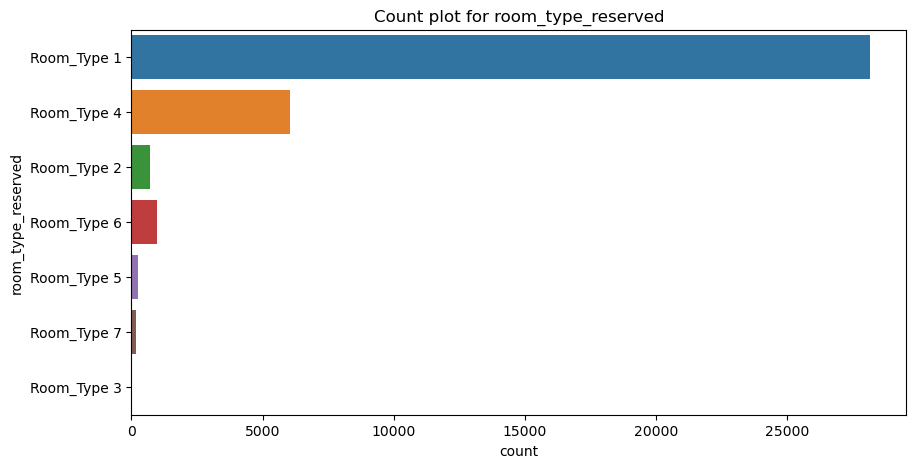

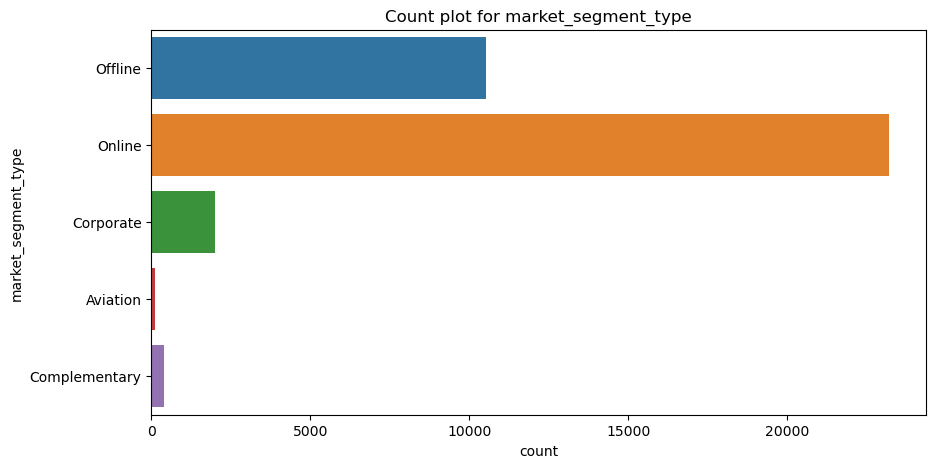

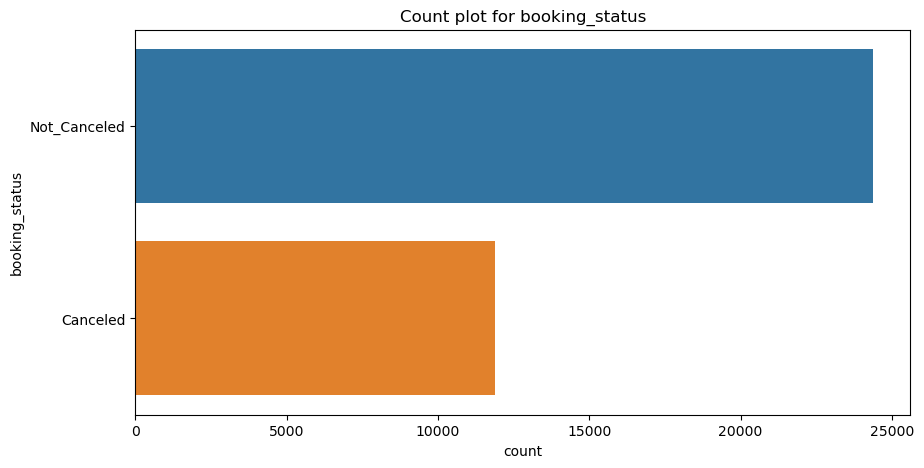

In [7]:
# I'm curious on categorical columns now.
cat_cols = data.select_dtypes(include=['object']).columns
cat_cols = cat_cols.drop('date_of_arrival')

# Plot count plots for each categorical column
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(y=data[col])  # Changed to horizontal bar plot for better readability
    plt.title(f'Count plot for {col}')
    plt.show()

## I have a general idea of what the breakdown looks like. Let's hone in on what concerns me.

In [8]:
# Metrics of interest
metrics = ['lead_time', 'room_type_reserved', 'type_of_meal_plan', 'market_segment_type', 'no_of_previous_cancellations', 
           'no_of_previous_bookings_not_canceled', 'no_of_special_requests', 'booking_status']

data_filtered = data[metrics]

/Users/vinlee/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


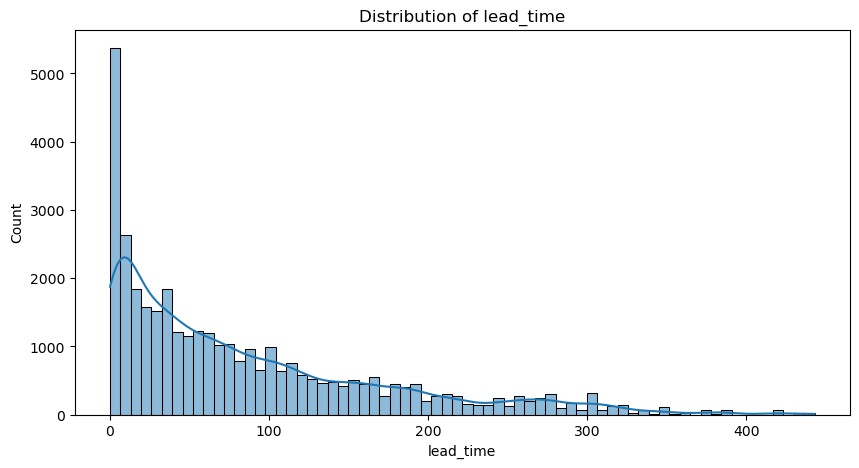

/Users/vinlee/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


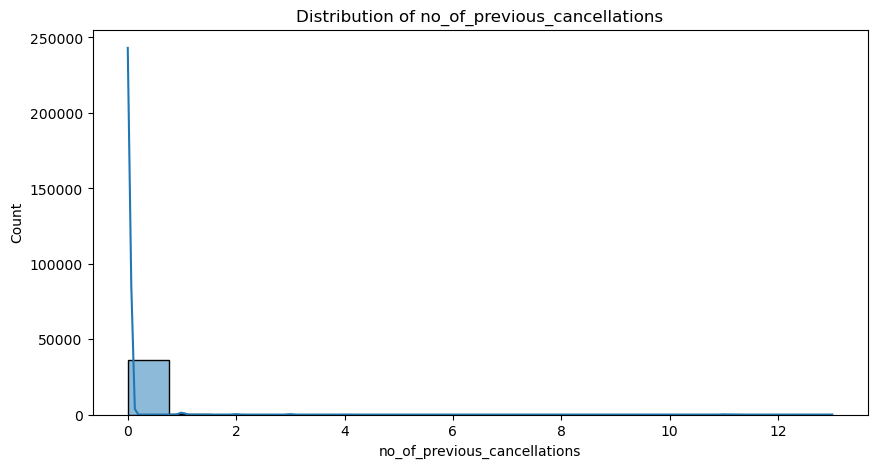

/Users/vinlee/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


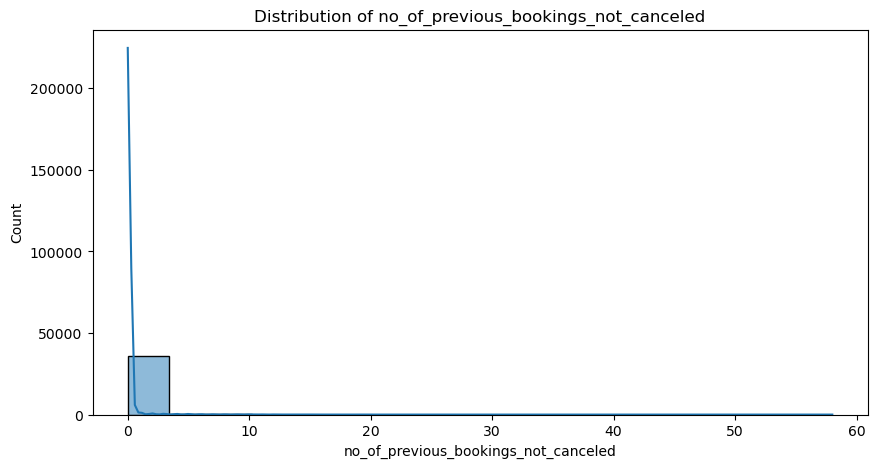

/Users/vinlee/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


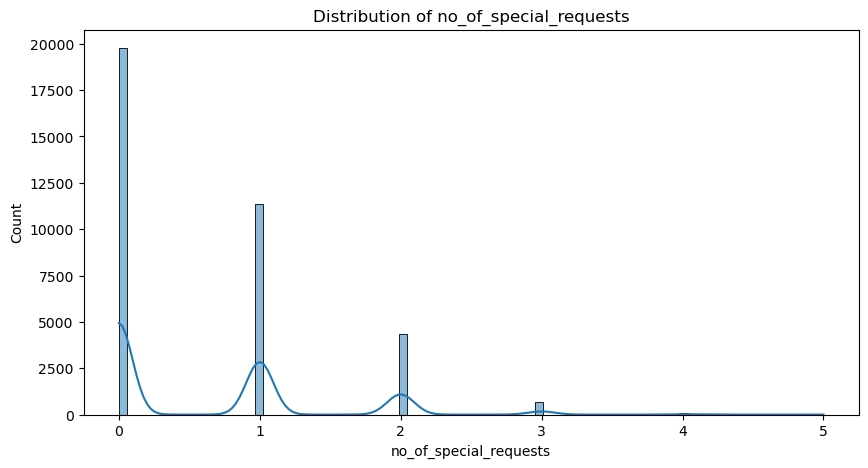

In [9]:
numeric_features = ['lead_time', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'no_of_special_requests']
for col in numeric_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(data_filtered[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

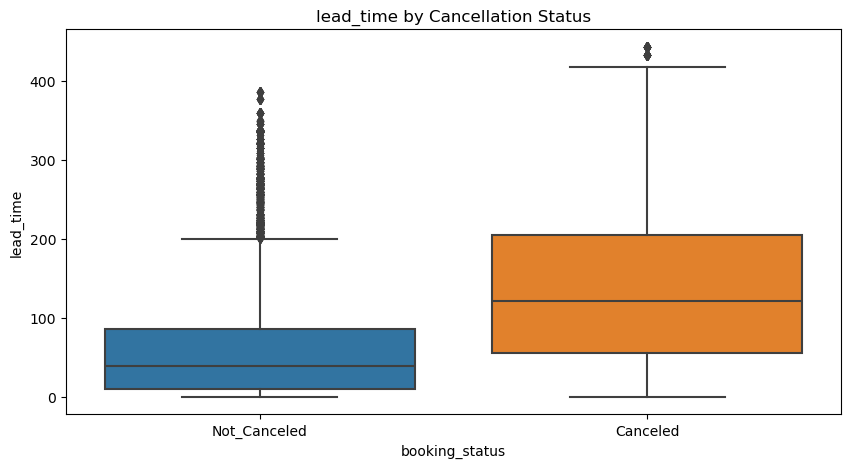

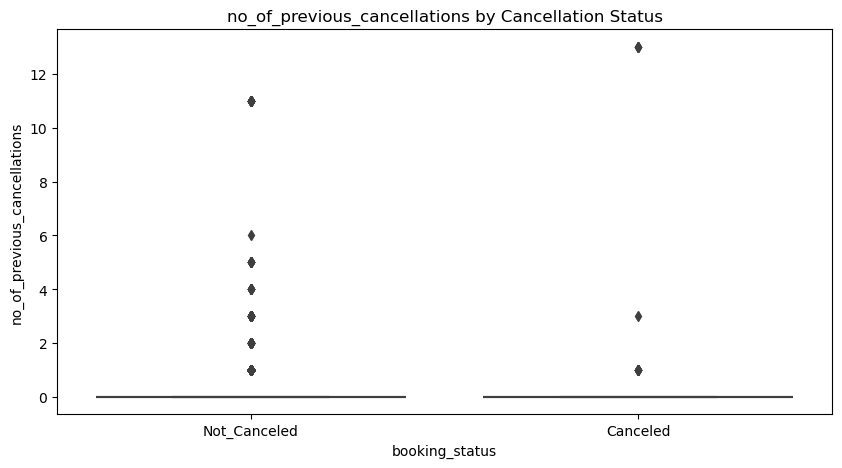

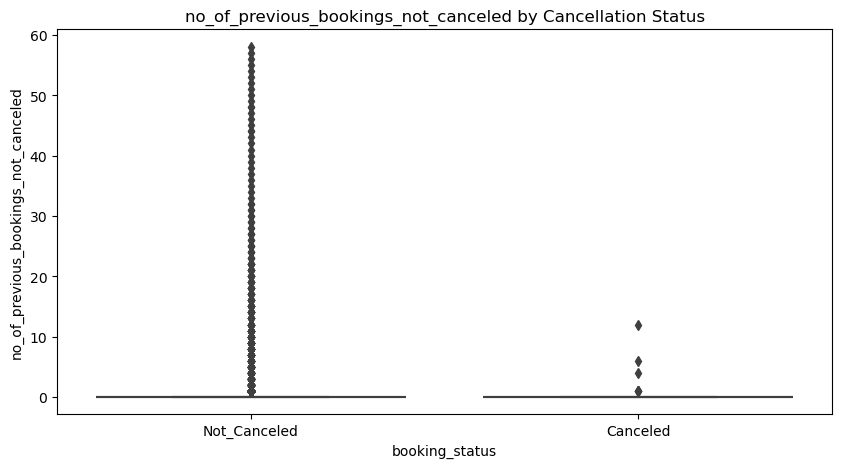

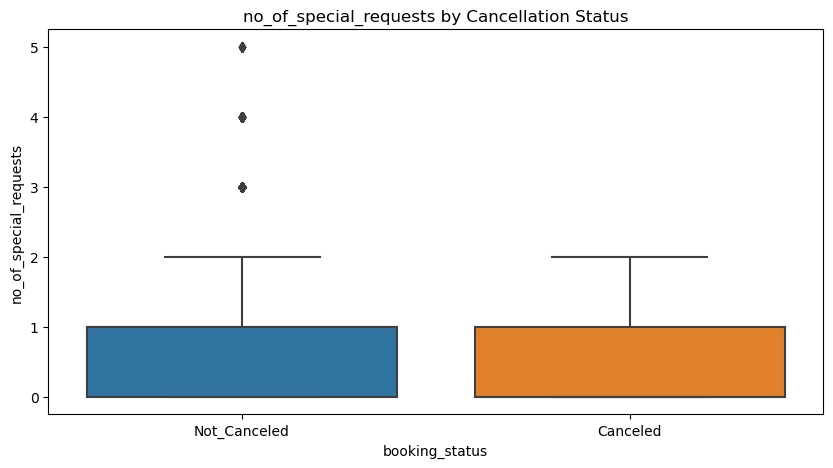

In [10]:
for col in numeric_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=data_filtered['booking_status'], y=data_filtered[col])
    plt.title(f'{col} by Cancellation Status')
    plt.show()

#Interesting. Lead time seems to be the real determining factor.

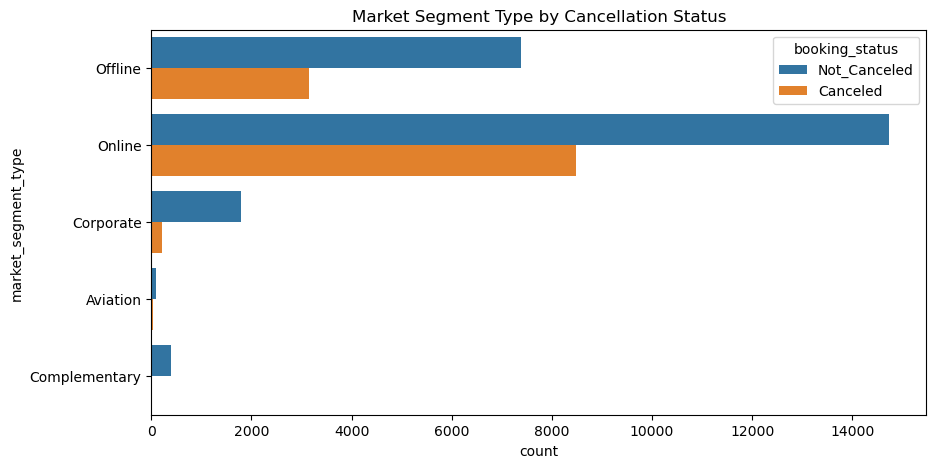

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(y=data_filtered['market_segment_type'], hue=data_filtered['booking_status'])
plt.title('Market Segment Type by Cancellation Status')
plt.show()

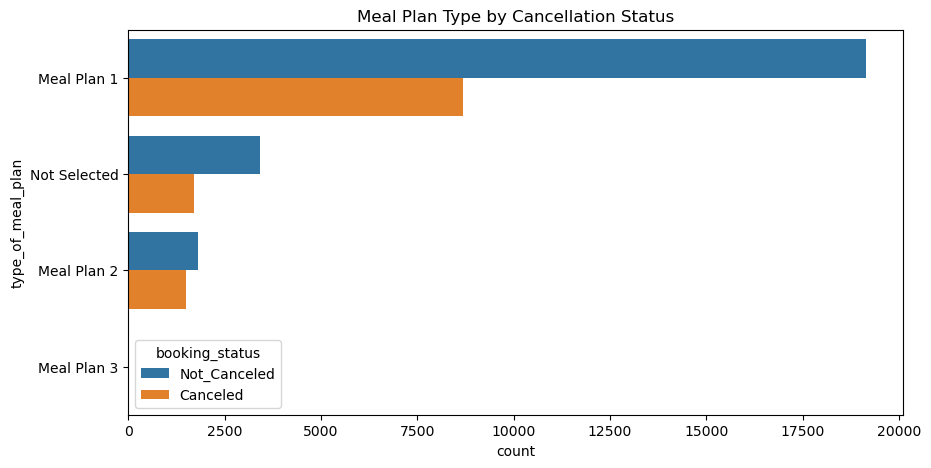

In [12]:
plt.figure(figsize=(10, 5))
sns.countplot(y=data_filtered['type_of_meal_plan'], hue=data_filtered['booking_status'])
plt.title('Meal Plan Type by Cancellation Status')
plt.show()

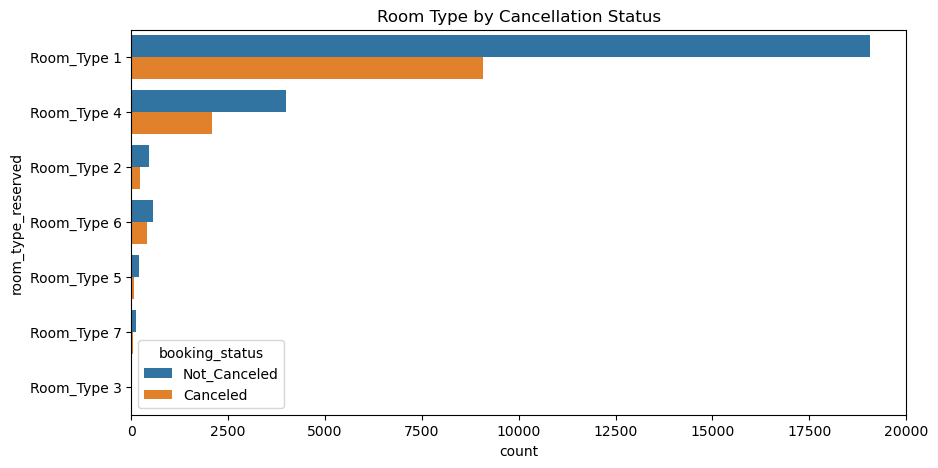

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(y=data_filtered['room_type_reserved'], hue=data_filtered['booking_status'])
plt.title('Room Type by Cancellation Status')
plt.show()

In [22]:
from scipy.stats import chi2_contingency, ttest_ind, f_oneway


contingency_table = pd.crosstab(data_filtered['market_segment_type'], data_filtered['booking_status'])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f'Chi-Square Test: chi2={chi2}, p-value={p}')

Chi-Square Test: chi2=814.108865240557, p-value=6.748763024557236e-175


In [17]:
contingency_table = pd.crosstab(data_filtered['room_type_reserved'], data_filtered['booking_status'])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f'Chi-Square Test: chi2={chi2}, p-value={p}')

Chi-Square Test: chi2=57.33495179790707, p-value=1.5627796772447482e-10


In [18]:
contingency_table = pd.crosstab(data_filtered['type_of_meal_plan'], data_filtered['booking_status'])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f'Chi-Square Test: chi2={chi2}, p-value={p}')

Chi-Square Test: chi2=278.29490920586017, p-value=4.951915406087789e-60


In [25]:
# Define the response variable
response_variable = 'booking_status'  # or 'cancellation_status' if that is the correct column name

# Numerical features
numerical_features = ['lead_time', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'no_of_special_requests']

# Remove rows with missing or infinite values in numerical features
data_cleaned = data.dropna(subset=numerical_features)
data_cleaned = data_cleaned[np.isfinite(data_cleaned[numerical_features]).all(axis=1)]

# Check group sizes and summary statistics
print(data_cleaned[response_variable].value_counts())
for feature in numerical_features:
    print(f'\nSummary statistics for {feature}:')
    print(data_cleaned.groupby(response_variable)[feature].describe())

# Run T-tests for each numerical feature against the response variable
for feature in numerical_features:
    group1 = data_cleaned[data_cleaned[response_variable] == 0][feature]
    group2 = data_cleaned[data_cleaned[response_variable] == 1][feature]
    if len(group1) > 1 and len(group2) > 1:  # Ensure there are enough samples
        t_stat, p_val = ttest_ind(group1, group2, nan_policy='omit')
        print(f'T-test for {feature}: t-statistic={t_stat}, p-value={p_val}')
    else:
        print(f'T-test for {feature} could not be performed due to insufficient data in one of the groups.')

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

Summary statistics for lead_time:
                  count        mean        std  min   25%    50%    75%    max
booking_status                                                                
Canceled        11885.0  139.215482  98.947731  0.0  55.0  122.0  205.0  443.0
Not_Canceled    24390.0   58.927224  64.028714  0.0  10.0   39.0   86.0  386.0

Summary statistics for no_of_previous_cancellations:
                  count      mean       std  min  25%  50%  75%   max
booking_status                                                       
Canceled        11885.0  0.005553  0.241941  0.0  0.0  0.0  0.0  13.0
Not_Canceled    24390.0  0.032021  0.415967  0.0  0.0  0.0  0.0  11.0

Summary statistics for no_of_previous_bookings_not_canceled:
                  count      mean       std  min  25%  50%  75%   max
booking_status                                                       
Canceled        11885.0  0.0

## I think this dataset will work for my upcoming project!